## Samelson model of the Berkley Jet
The Bickley jet

In [12]:
# Base imports and path setting
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import jax
import jax.numpy as jnp
import diffrax as dfx
from time import time

import sys
import os
from os.path import dirname
cwd = os.getcwd()
sys.path.append(dirname(cwd))


In [13]:
# Relative import and macroscopic configs
from src.flows import samelson_flow, trajectory_plot, stream_plot
from src.lyapunov import *

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(seed=42069)
FIG_PATH = dirname(cwd) + "/figs/"

In [14]:
# Flow selection and parameters
rhs = samelson_flow
pars = {
    "A0": 1.064,
    "C": 0.25,
    "L": 2,
    "h": 0.07,
    "wf": 0.058,
}

# Initial condition, integration options
z0 = jnp.array([1, 1])
dt = 0.001
N_iters = 2e5
timesteps = np.linspace(0, dt*N_iters, 500000)

steps = 1
burns = 0.2

solver = dfx.Kvaerno5()
stepsc = dfx.PIDController(rtol=1e-8, atol=1e-8)
term = dfx.ODETerm(rhs)
saveat = dfx.SaveAt(ts=timesteps)

# Graph boundaries and grids
X_space = np.linspace(-2*np.pi, 2*np.pi, 400)
Y_space = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(X_space, Y_space)
U, V = rhs(t=0, z=(X, Y), params=pars)

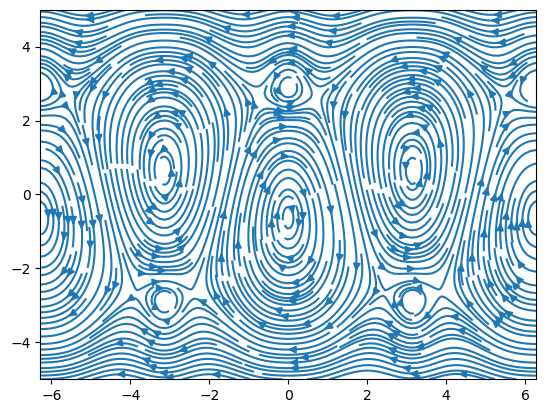

In [15]:
# Animation of the flow
starting_lines = np.array([i.flatten() for i in np.meshgrid(
                            np.linspace(-2*np.pi, 2*np.pi, 200),
                            np.linspace(-5, 5, 200),
                            indexing="ij"
                           )]).T

dens=3

fig, ax = plt.subplots()
stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)

def animate(ti):
    ax.clear()
    ax.grid(True)
    U, V = rhs(t=ti, z=(X, Y), params=pars)
    stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)
    print(ti)
    return stream

#anim = animation.FuncAnimation(fig, animate, frames=np.linspace(0, 2*np.pi/pars.get("wf", 1), 100), interval=50, blit=False, repeat=False)
#anim.save( FIG_PATH + '/samelson.gif', writer='imagemagick', fps=30)
# plt.show()


In [5]:
# Baseline: unperturbed map integration
rand_flurry = jnp.array([rng.random(100)*4*np.pi - 2*np.pi, rng.random(100)*8 - 4]).T

# Trajectories plot

In [6]:
# First experiment: lyapunov exponents for 100 random initial condition

# Define random ranges
t0_batch = jnp.zeros(len(rand_flurry))

# Build mappable function
rand_compute = make_batch_lyapunov_solver(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns))
batched_lyap = jax.jit(
    jax.vmap(rand_compute, in_axes=(0, 0, None, None))
)

# Execute
rand_trajects, rand_cum_lyaps = batched_lyap(rand_flurry, t0_batch, pars, steps*dt)

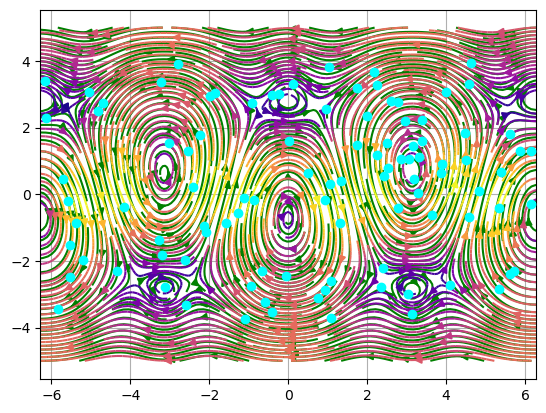

NameError: name 'rand_cum_lyaps' is not defined

In [10]:
# Flow at different times with flurry
plt.streamplot(X, Y, U , V, density=3, color="green",)
U_flur, V_flur = rhs(t=np.pi/(pars.get("wf")), z=(X, Y), params=pars)
plt.streamplot(X, Y, U_flur, V_flur, density=3, color=np.sqrt(U_flur**2 + V_flur**2), cmap='plasma',)
plt.scatter(*rand_flurry.T, c="cyan", zorder=10)
plt.grid()
plt.savefig(FIG_PATH + "Flurry_flow.png", dpi=1500)
plt.show()

# Plot and results
for cum in rand_cum_lyaps:
    plt.plot(cum)
plt.grid(True)
plt.savefig(FIG_PATH + "Rand_lyaps.png")
plt.show(cwd + '/samelson_lyap100.png')
lyap_ext = rand_cum_lyaps.mean(axis=0)[-1, :]
lyap_std = rand_cum_lyaps.std(axis=0)[-1, :]
print(f"Lyapunov exponents extimate (averaged over random trajectories): {lyap_ext} +- {lyap_std}")

# Trajectories
rand_trajects_trasp = np.transpose(rand_trajects, axes=(0, -1, -2))
#with plt.style.context('Solarize_Light2'):
plt.xlim(left=-10)
for traj in rand_trajects_trasp:
    plt.plot(*traj, linewidth=0.8)
plt.grid(True)
plt.savefig(FIG_PATH + "Rand_trajects.png", dpi=1500)
plt.show()


### Interpretazione del risultato
La stima dei coefficienti di Lyapunov è entro 2 sigma dallo zero, fatto che potrebbe essere dato dalla quantità relativamente alta di punti inizializzati all'interno delle strutture cicloidi del flusso, che rimangono intrappolati in traiettorie dalle quali è difficile scappare.
Dalla figura infatti se ne vedono alcune che rimangono all'interno delle cicloidi, sia grandi che piccole, oppure ancora nei flussi sopra e sotto l'area centrale nell'asse y, anche se queste vediamo che possono rientrare nella serpentina.
In conclusione, stimare come media su condizioni random potrebbe non portare a risultati significativi, in quanto vi sono zone della mappa dal comportamento qualitativamente diverso, e non è detto che queste comunichino per l'ampiezza di perturbazione considerata.

In [16]:
# Second experiment: non-random condition

# Define points
flurry = jnp.concat([jnp.array([jnp.linspace(-jnp.pi, jnp.pi, 30), jnp.zeros(30)]).T,
                     jnp.array([jnp.linspace(-jnp.pi/2, jnp.pi/2, 10), jnp.full(10, 2.75)]).T,
                     jnp.array([jnp.linspace(-jnp.pi*3/2, -jnp.pi/2, 10), jnp.full(10, -2.75)]).T,
                                ])
t0_batch = jnp.zeros(len(flurry))

# Build mappable function
flurry_compute = make_batch_lyapunov_solver(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns))
batched_lyap = jax.jit(
    jax.vmap(flurry_compute, in_axes=(0, 0, None, None))
)

# Execute
flurry_trajects, flurry_cum_lyaps = batched_lyap(flurry, t0_batch, pars, steps*dt)

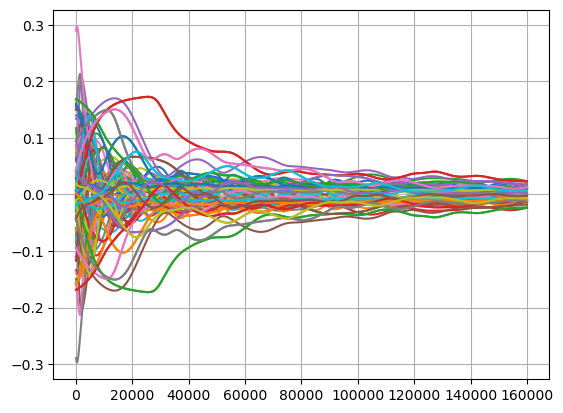

Lyapunov exponents extimate (averaged over random trajectories): [ 0.00733318 -0.00733318] +- [0.00840542 0.00840542]


/home/mapianini/Projects/Sistemi Complessi/Esame/src/lyapunov.py:51: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots()


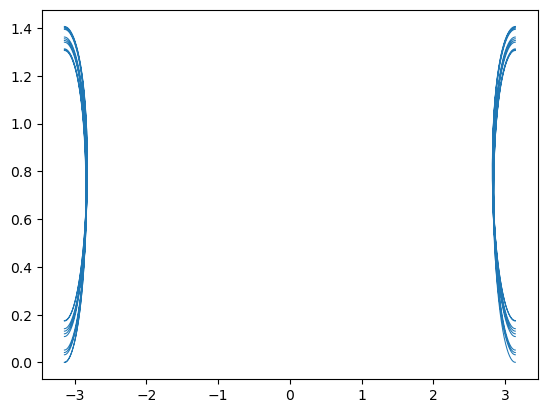

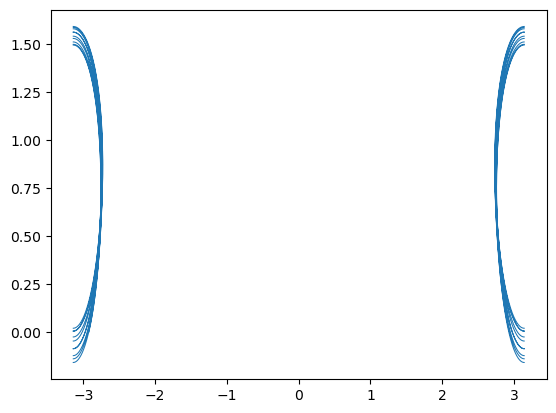

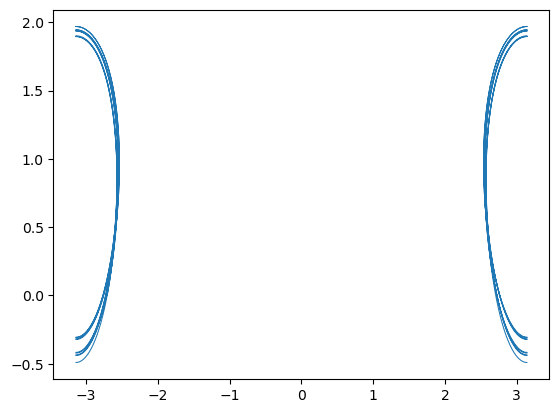

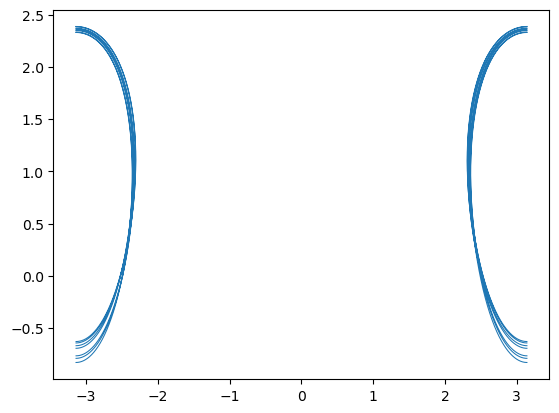

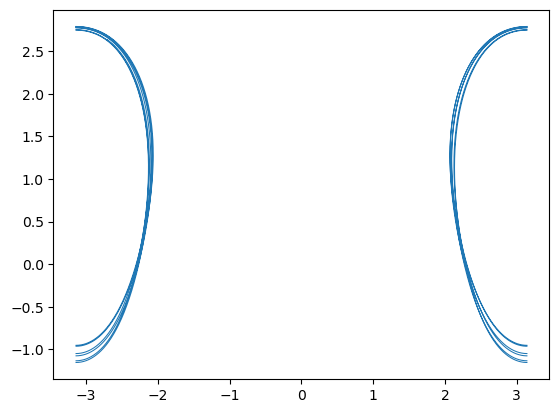

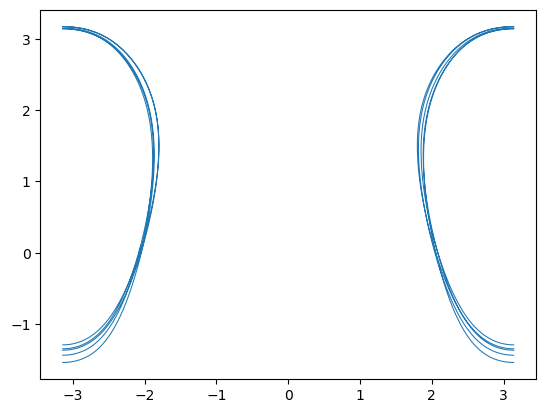

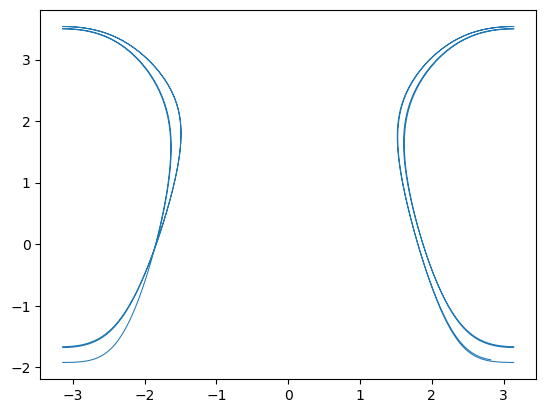

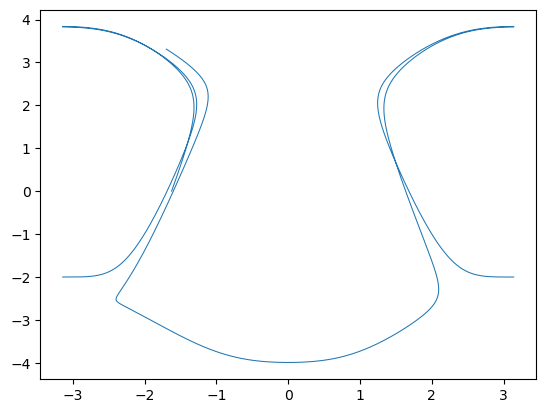

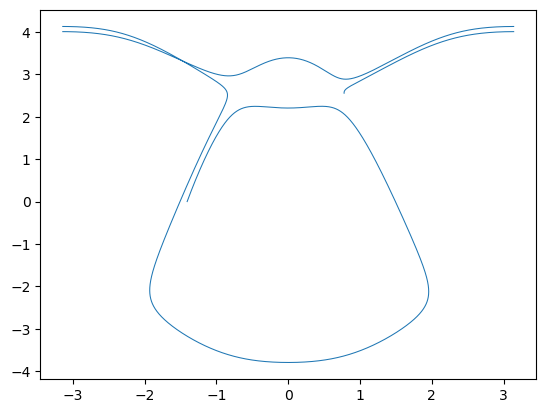

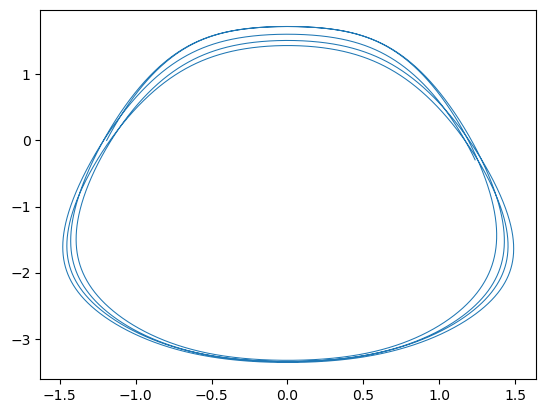

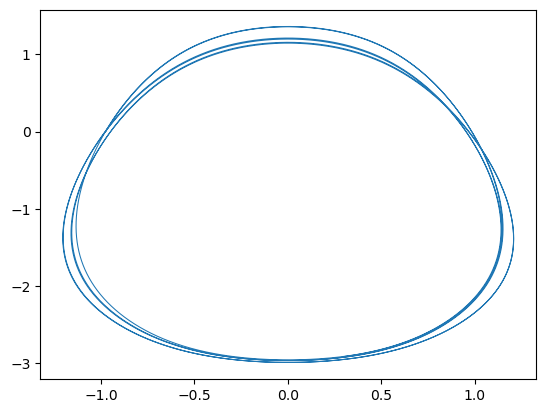

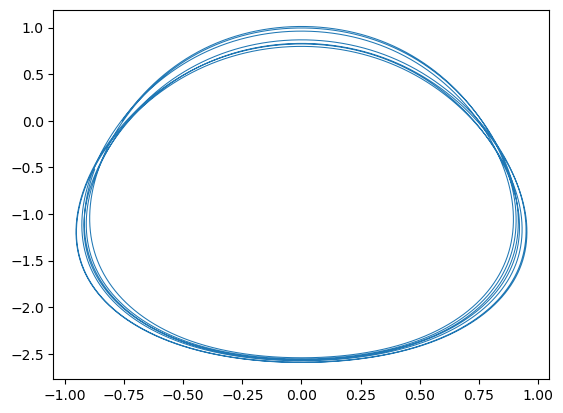

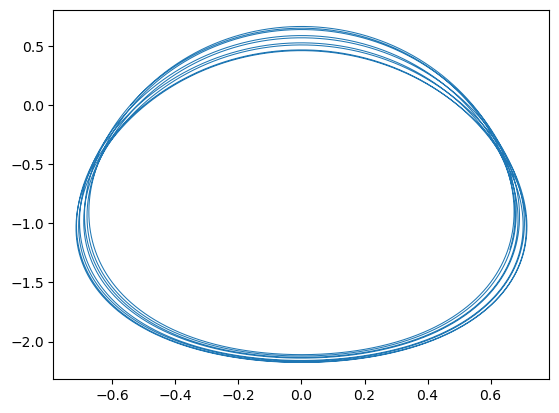

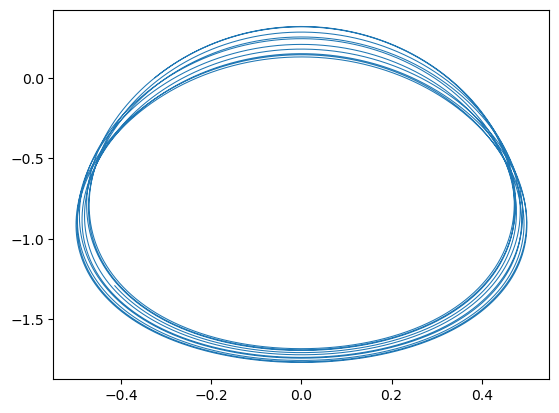

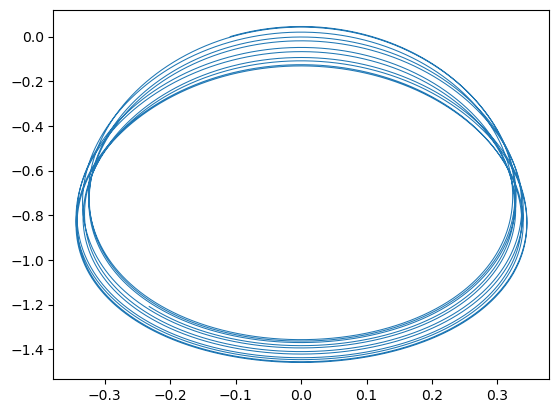

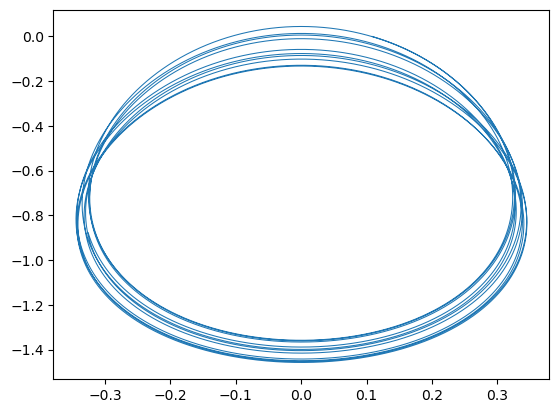

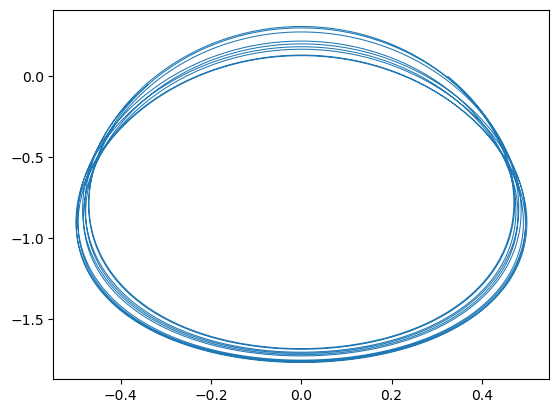

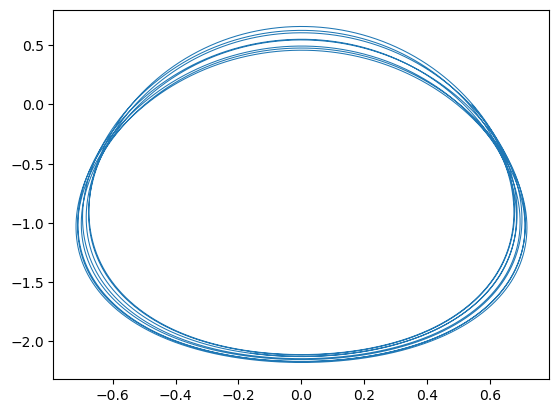

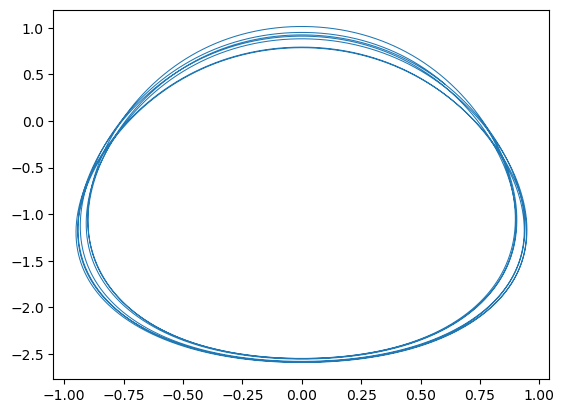

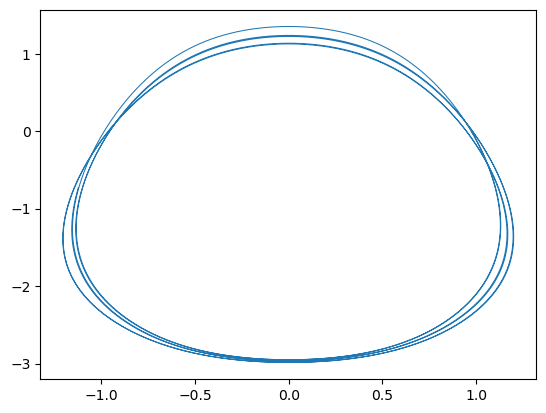

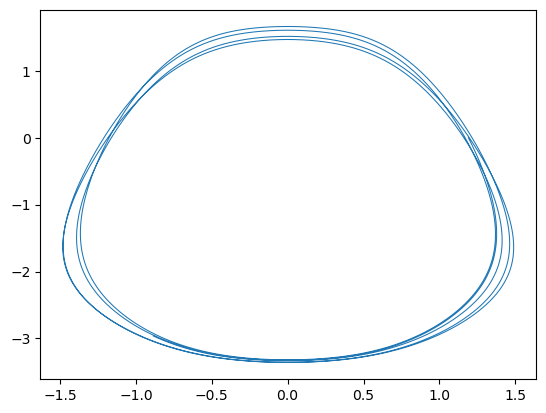

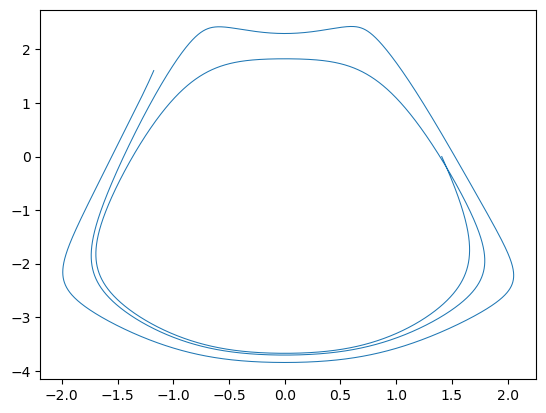

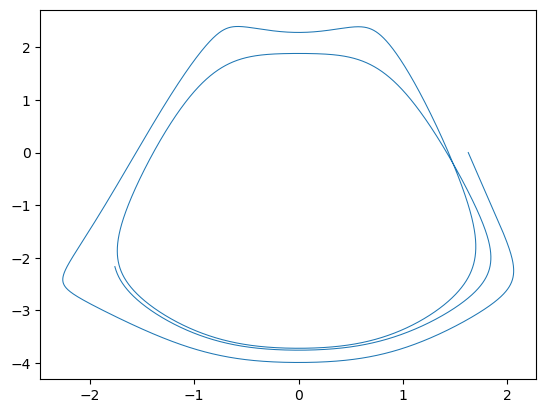

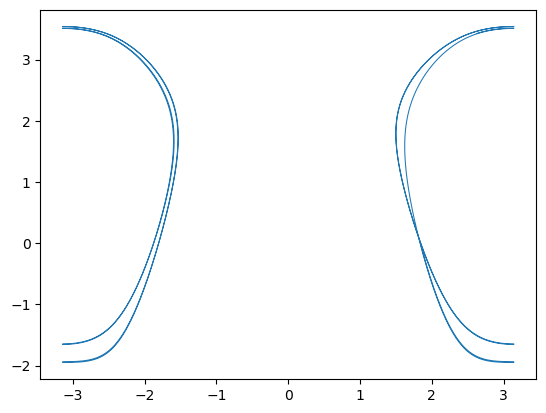

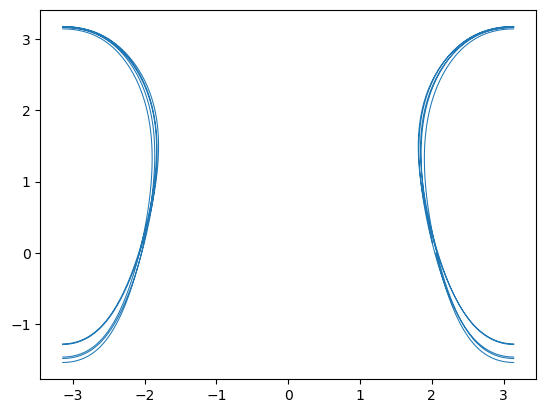

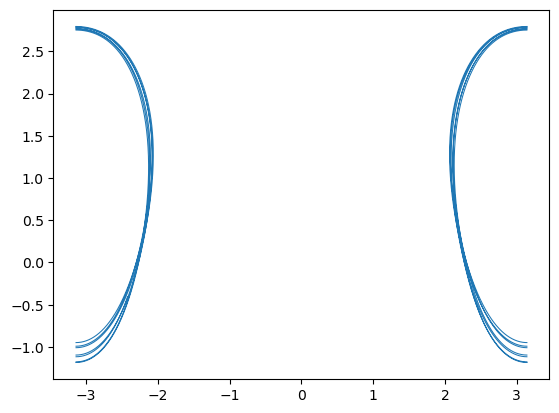

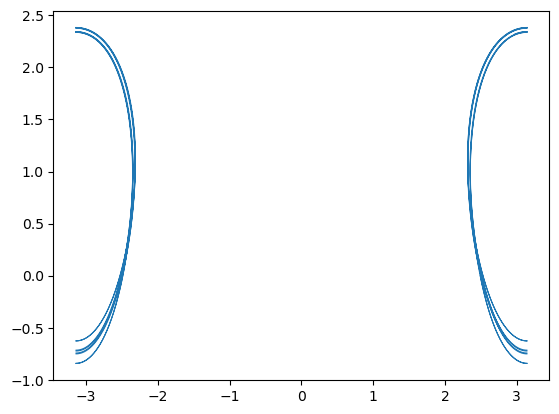

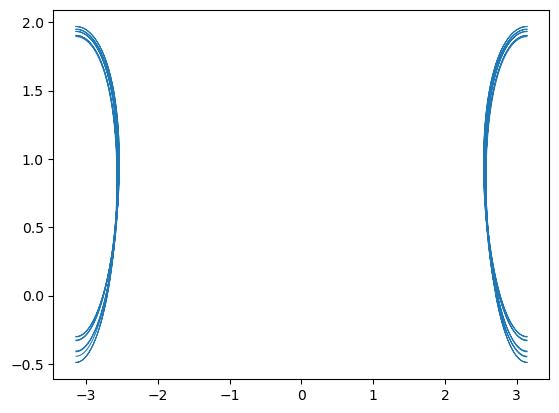

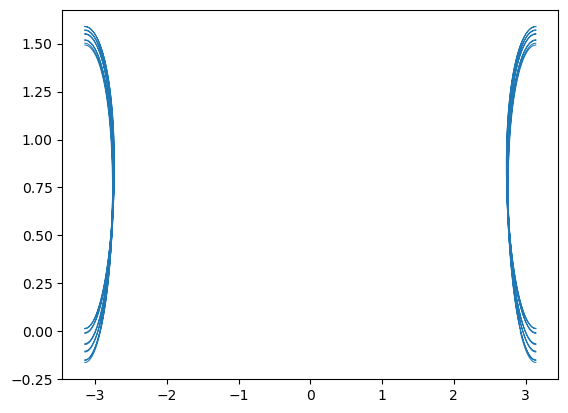

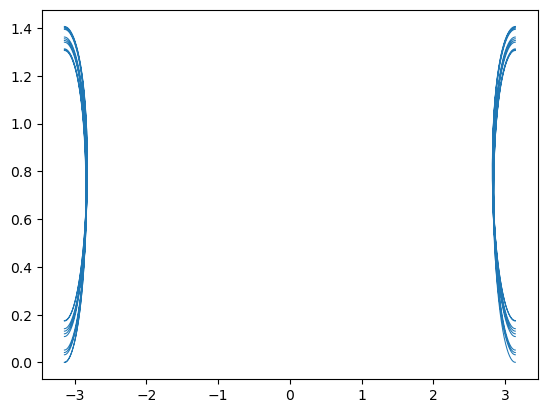

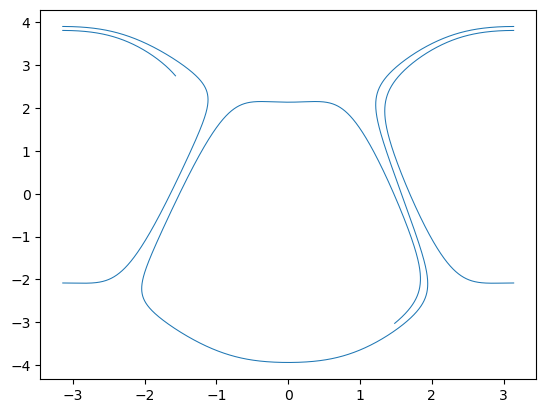

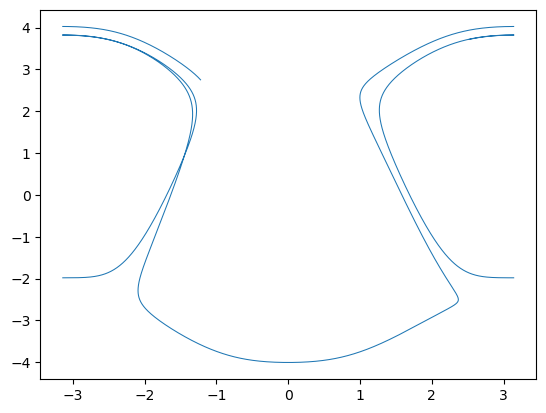

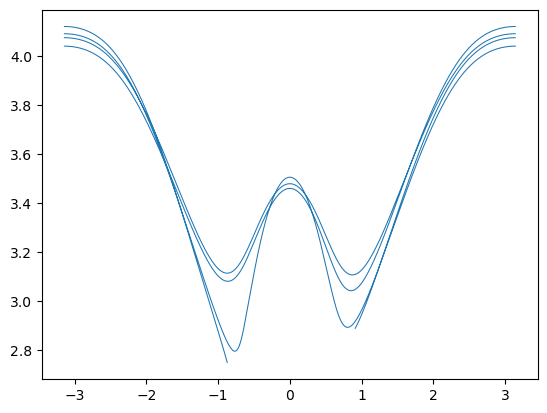

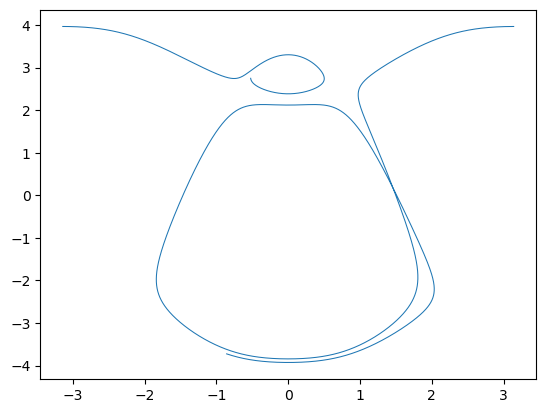

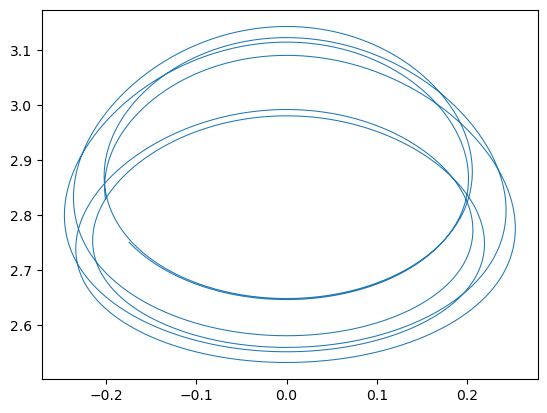

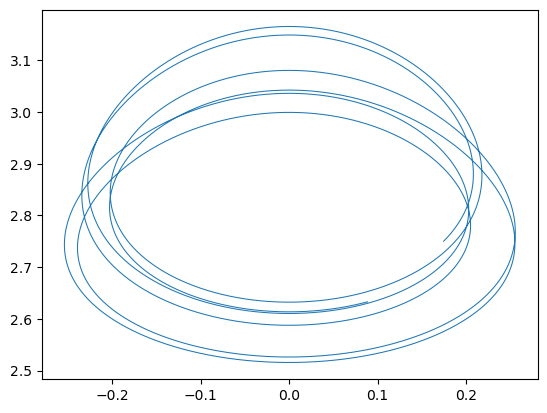

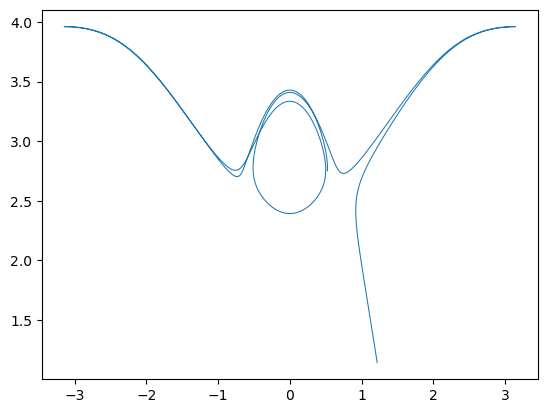

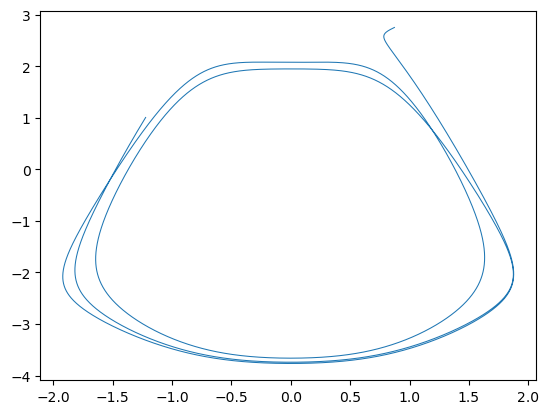

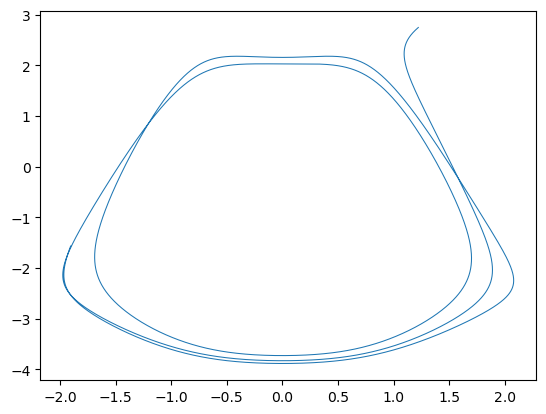

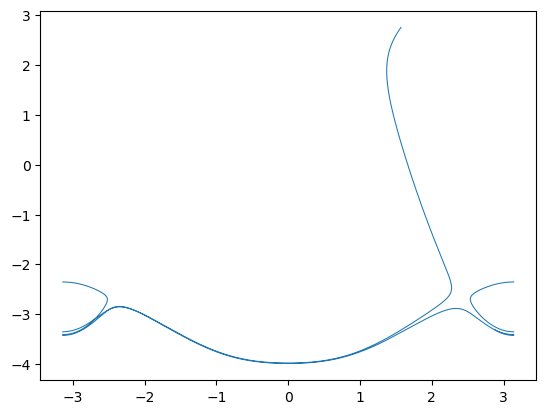

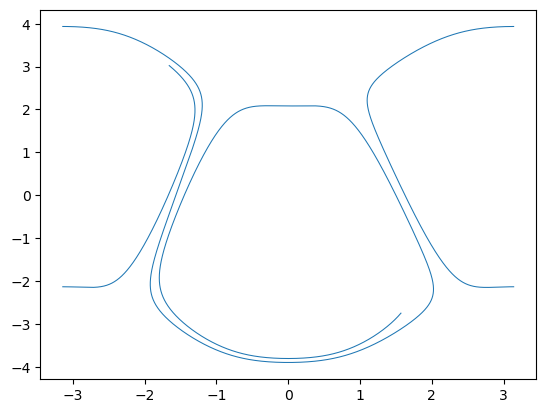

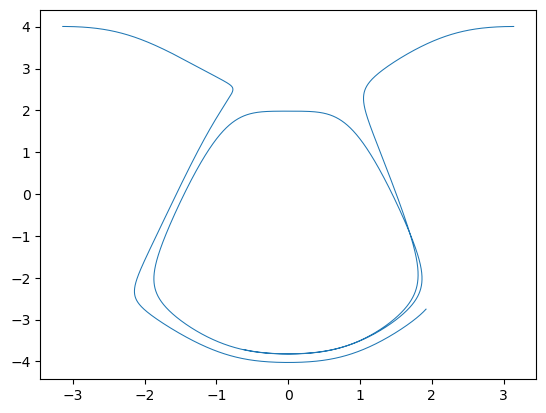

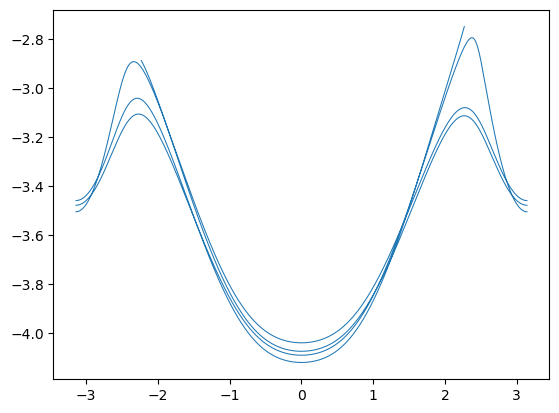

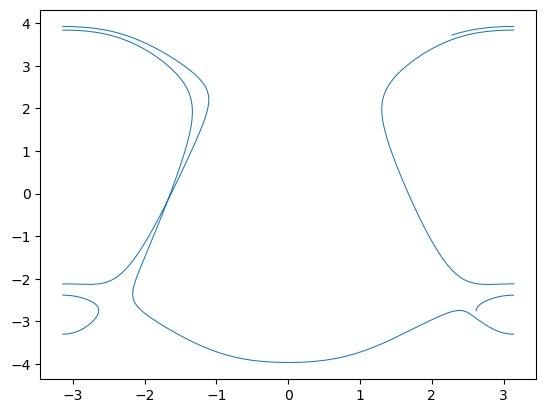

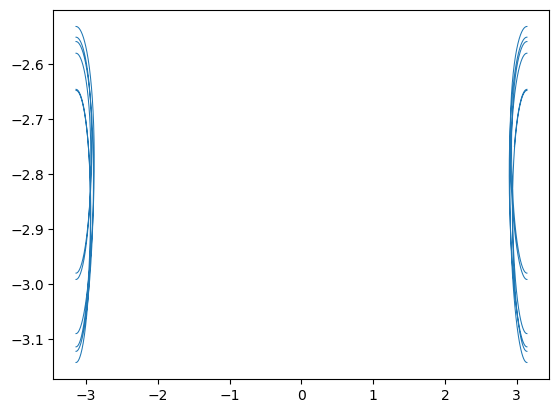

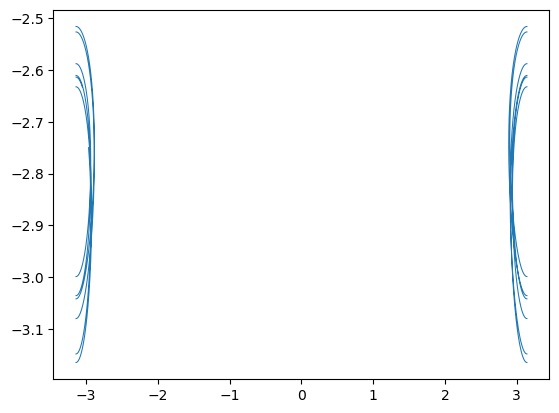

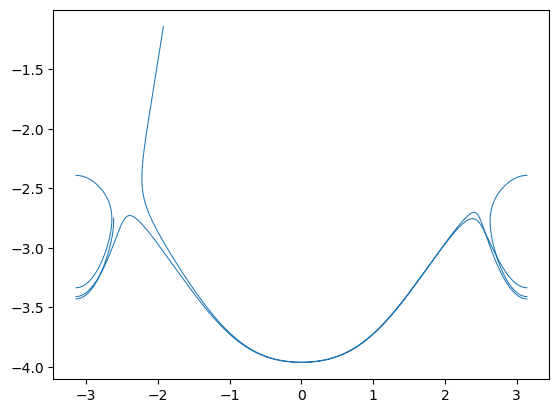

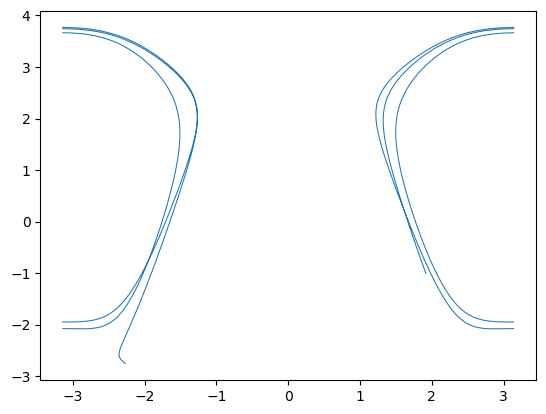

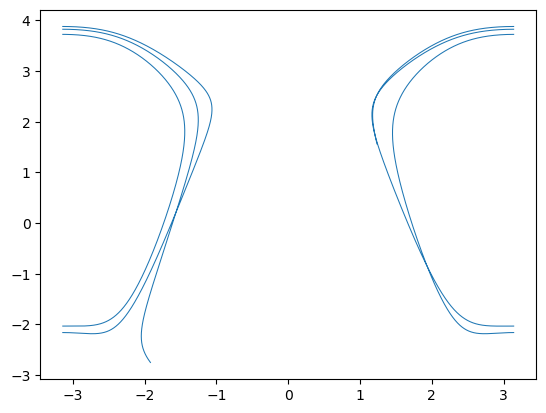

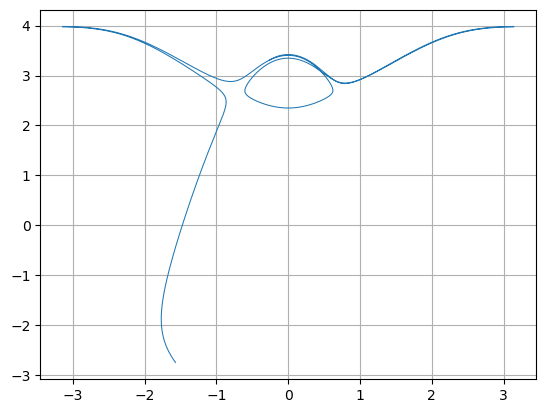

In [17]:
# Plot and results
for cum in flurry_cum_lyaps:
    plt.plot(cum)
plt.grid(True)
plt.savefig(FIG_PATH + "Rand_lyaps.png")
plt.show(cwd + '/samelson_lyap100.png')
lyap_ext = flurry_cum_lyaps.mean(axis=0)[-1, :]
lyap_std = flurry_cum_lyaps.std(axis=0)[-1, :]
print(f"Lyapunov exponents extimate (averaged over random trajectories): {lyap_ext} +- {lyap_std}")

# Trajectories
flurry_trajects_trasp = np.transpose(flurry_trajects, axes=(0, -1, -2))
#with plt.style.context('Solarize_Light2'):
for traj in flurry_trajects_trasp:
    plot_wrapped(*traj, linewidth=0.75)
plt.grid(True)
plt.savefig(FIG_PATH + "Rand_trajects.png", dpi=1500)
plt.show()


### Interpretazione del risultato


In [ ]:
# Third experiment: parameters variation
# Setup and calculations
z0 = jnp.array([np.pi/2, 0])
pars_list = pars.copy()
pars_list.update({"h": jnp.linspace(0, 1, 11)})

var_compute = make_batch_lyapunov_solver(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns), jacobian=False)
var_lyap_ext = jax.jit(
    jax.vmap(var_compute, in_axes=(None, None, {"A0": None, "C": None, "L": None, "h": 0, "wf": None}, None))
)

var_trajects, var_cum_lyaps = var_lyap_ext(z0, 0, pars_list, steps*dt)


Lyapunov exponents extimate for perturbation amplitude = 0.0: [-0.01338874  0.01338874]
Lyapunov exponents extimate for perturbation amplitude = 0.1: [ 0.01466907 -0.01466907]
Lyapunov exponents extimate for perturbation amplitude = 0.2: [ 0.00296471 -0.00296471]
Lyapunov exponents extimate for perturbation amplitude = 0.30000000000000004: [ 0.01323811 -0.01323811]
Lyapunov exponents extimate for perturbation amplitude = 0.4: [ 0.01304558 -0.01304558]
Lyapunov exponents extimate for perturbation amplitude = 0.5: [ 0.00627622 -0.00627622]
Lyapunov exponents extimate for perturbation amplitude = 0.6000000000000001: [ 0.00849324 -0.00849324]
Lyapunov exponents extimate for perturbation amplitude = 0.7000000000000001: [ 0.0006102 -0.0006102]
Lyapunov exponents extimate for perturbation amplitude = 0.8: [ 0.00027415 -0.00027415]
Lyapunov exponents extimate for perturbation amplitude = 0.9: [ 0.02561946 -0.02561946]
Lyapunov exponents extimate for perturbation amplitude = 1.0: [ 0.02162997 -

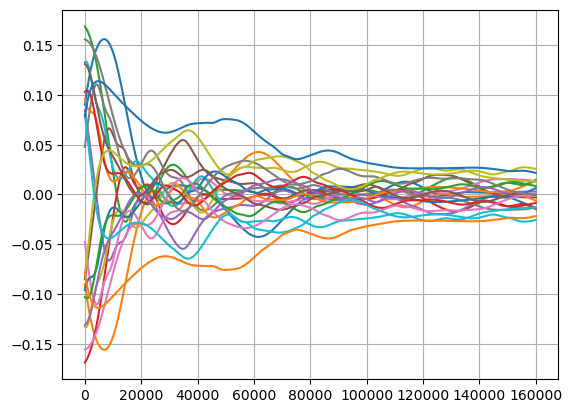

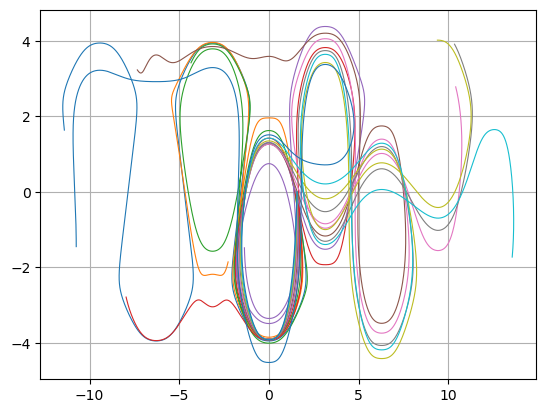

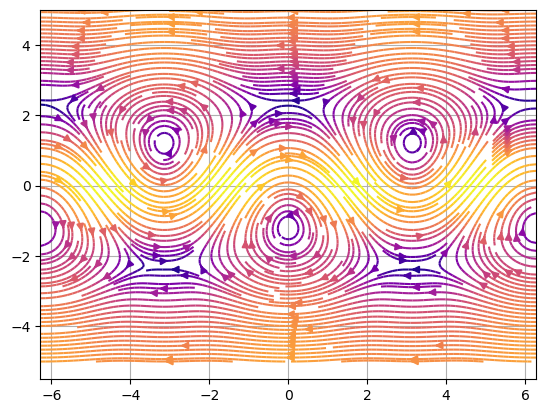

In [6]:
# Plots
for cum, h in zip(var_cum_lyaps, pars_list["h"]):
    print(f"Lyapunov exponents extimate for perturbation amplitude = {h}: {cum[-1]}")
    plt.plot(cum)
plt.grid(True)
plt.show()

# Trajectories
var_trajects_trasp = np.transpose(var_trajects, axes=(0, -1, -2))
for traj in var_trajects_trasp:
    plt.plot(*traj, linewidth=0.8)
plt.grid(True)
plt.savefig(FIG_PATH + "Var_trajects.png", dpi=1500)
plt.show()

# Perturbated flow
#plt.streamplot(X, Y, U , V, density=3)

pert_pars = pars.copy()

pert_pars.update({"h": 0.5})
U_full, V_full = rhs(t=np.pi/(pars.get("wf")), z=(X, Y), params=pert_pars)
plt.streamplot(X, Y, U_full, V_full, density=3, color=np.sqrt(U_full**2 + V_full**2), cmap='plasma')
plt.grid()
plt.savefig(FIG_PATH + "Sam_Perturbed_flow.png", dpi=1500)
plt.show()


### Interpretazioni del risultato
Vediamo che le prime cinque traiettorie graficate (secondo il cycling di default di matplotlib.pyplot.plot, dalla prima blu alla viola) seguono il flusso perturbato che è simile a quello analizzato in precedenza. 
Le utlime sei, invece, mostrano un andamento più erratico, con le ultime che saltano da una cicloide all'altra "tagliando" il flusso imperturbato, o addirittura procedendo nel verso contrario del flusso.
Andando poi a graficare il flusso a metà periodo della perturbazione (ampiezza h = 1) si nota la comparsa di un flusso centrale in senso opposto e la distruzione delle cicloidi più piccole.